In [8]:
# bloco de código para as funções
import random
from math import sin
telemetria = list()
centro = 10        # ponto médio entre -100 e 120
amplitude = 90     # controla o quanto varia
for i in range(50):
    variacao = amplitude * sin(i / 8) # mudança suave de temperatura
    ruido = random.uniform(-2, 2) # erro pequeno do sensor
    temperatura = centro + variacao + ruido
    temperatura = max(-100, min(120, temperatura)) # garante que fique dentro do intervalo
    telemetria.append(round(temperatura, 2))
print(telemetria)

# validar temperatura
def validar_temperatura(t):
  if float(t) < -100 or float(t) > 120:
    return False
  else:
    return True

# classificar temperatura
def classificar_temperatura(t):
  categoria = ''
  if float(t) < -40:
    categoria = 'Cold Case Crítico'
  elif -40 <= float(t) < -20:
    categoria = 'Frio'
  elif -20 <= float(t) <= 50:
    categoria = 'Nominal'
  elif 50 < float(t) <= 70:
    categoria = 'Quente'
  else:
    categoria = 'Hot Case Crítico'
  return categoria

# detectar picos e vales
def detectar_picos_vales(lista):
  pico_vale = list()
  quantidade_picos = 0
  quantidade_vales = 0
  for i in range(1, len(lista) - 1):
    if lista[i - 1] < lista[i] > lista[i + 1]:
      pico_vale.append([i * 3, float(lista[i]), 'Pico'])
      quantidade_picos += 1
    elif lista[i - 1] > lista[i] < lista[i + 1]:
      pico_vale.append([i * 3, float(lista[i]), 'Vale'])
      quantidade_vales += 1
  return pico_vale

# gerar relatorio
def gerar_relatorio(lista):
  cold_case = 0
  frio = 0
  nominal = 0
  quente = 0
  hot_case = 0
  if lista[0][2] == 'Cold Case Crítico' or lista[0][2] == 'Frio' or lista[0][2] == 'Nominal' or lista[0][2] == 'Quente' or lista[0][2] == 'Hot Case Crítico':
    for linha in lista:
      if linha[2] == 'Cold Case Crítico':
        cold_case += 1
      elif linha[2] == 'Frio':
        frio += 1
      elif linha[2] == 'Nominal':
        nominal += 1
      elif linha[2] == 'Quente':
        quente += 1
      elif linha[2] == 'Hot Case Crítico':
        hot_case += 1
    return f'Quantidade de "Cold Case Crítico": {cold_case} ({(cold_case / len(lista)) * 100:.2f}%)\nQuantidade de "Nominal": {nominal} ({(nominal / len(lista)) * 100:.2f}%)\nQuantidade de "Frio": {frio} ({(frio / len(lista)) * 100:.2f}%)\nQuantidade de "Quente": {quente} ({(quente / len(lista)) * 100:.2f}%)\nQuantidade de "Hot Case Crítico": {hot_case} ({(hot_case / len(lista)) * 100:.2f}%)'
  quantidade_picos = 0
  quantidade_vales = 0
  if lista[0][2] == 'Pico' or lista[0][2] == 'Vale':
    for linha in lista:
      if linha[2] == 'Pico':
        quantidade_picos += 1
      elif linha[2] == 'Vale':
        quantidade_vales += 1
  return f'Quantidade de "Picos": {quantidade_picos}\nQuantidade de "Vales": {quantidade_vales}'
  

[9.44, 21.82, 31.86, 41.26, 53.21, 63.99, 72.11, 77.7, 86.44, 90.63, 94.39, 96.37, 100.17, 100.37, 99.92, 94.66, 92.36, 87.96, 81.29, 73.85, 63.6, 56.35, 45.76, 34.9, 23.93, 10.62, -0.15, -12.76, -19.64, -30.2, -40.03, -50.91, -56.29, -64.61, -70.71, -73.55, -78.09, -77.86, -80.87, -77.52, -78.09, -73.29, -69.27, -62.69, -52.59, -45.06, -36.01, -24.76, -16.28, -2.7]


In [9]:
# 2 validar a temperatura
telemetria_invalida = list()
telemetria_valida = list()
for temperatura in telemetria:
  if validar_temperatura(temperatura):
    telemetria_valida.append(temperatura)
  else:
    telemetria_invalida.append(temperatura)
telemetria = telemetria_valida

print(telemetria)
if len(telemetria_invalida) > 0:
  print(f'A telemetria possuia alguns dados inválidos, que ja foram removidos de nossa telemetria principal.')
  print(f'Restaram {len(telemetria)} dados para serem análisados.')
  print(f'Aqui estão os dados inválidos captados: {telemetria_invalida}')
else:
  print('Não foram encontrados dados inválidos na telemetria.')

[9.44, 21.82, 31.86, 41.26, 53.21, 63.99, 72.11, 77.7, 86.44, 90.63, 94.39, 96.37, 100.17, 100.37, 99.92, 94.66, 92.36, 87.96, 81.29, 73.85, 63.6, 56.35, 45.76, 34.9, 23.93, 10.62, -0.15, -12.76, -19.64, -30.2, -40.03, -50.91, -56.29, -64.61, -70.71, -73.55, -78.09, -77.86, -80.87, -77.52, -78.09, -73.29, -69.27, -62.69, -52.59, -45.06, -36.01, -24.76, -16.28, -2.7]
Não foram encontrados dados inválidos na telemetria.


In [10]:
# 3 identificar a categoria conforme a tabela de classificação térmica
lista_classificacoes = list()
for indice, temperatura in enumerate(telemetria):
  classificacao = classificar_temperatura(temperatura)
  lista_classificacoes.append([indice * 3, float(temperatura), classificacao])
print('min / Temp. / Class.')
display(lista_classificacoes)
# a lista armazena [minuto, temperatura, classificacao]

min / Temp. / Class.


[[0, 9.44, 'Nominal'],
 [3, 21.82, 'Nominal'],
 [6, 31.86, 'Nominal'],
 [9, 41.26, 'Nominal'],
 [12, 53.21, 'Quente'],
 [15, 63.99, 'Quente'],
 [18, 72.11, 'Hot Case Crítico'],
 [21, 77.7, 'Hot Case Crítico'],
 [24, 86.44, 'Hot Case Crítico'],
 [27, 90.63, 'Hot Case Crítico'],
 [30, 94.39, 'Hot Case Crítico'],
 [33, 96.37, 'Hot Case Crítico'],
 [36, 100.17, 'Hot Case Crítico'],
 [39, 100.37, 'Hot Case Crítico'],
 [42, 99.92, 'Hot Case Crítico'],
 [45, 94.66, 'Hot Case Crítico'],
 [48, 92.36, 'Hot Case Crítico'],
 [51, 87.96, 'Hot Case Crítico'],
 [54, 81.29, 'Hot Case Crítico'],
 [57, 73.85, 'Hot Case Crítico'],
 [60, 63.6, 'Quente'],
 [63, 56.35, 'Quente'],
 [66, 45.76, 'Nominal'],
 [69, 34.9, 'Nominal'],
 [72, 23.93, 'Nominal'],
 [75, 10.62, 'Nominal'],
 [78, -0.15, 'Nominal'],
 [81, -12.76, 'Nominal'],
 [84, -19.64, 'Nominal'],
 [87, -30.2, 'Frio'],
 [90, -40.03, 'Cold Case Crítico'],
 [93, -50.91, 'Cold Case Crítico'],
 [96, -56.29, 'Cold Case Crítico'],
 [99, -64.61, 'Cold Case Cr

In [11]:
# 4 mapear as inversões de tendência térmica
pv = detectar_picos_vales(telemetria)
display(pv)
# a lista armazena [minuto, temperatura, pico/vale]

[[39, 100.37, 'Pico'],
 [108, -78.09, 'Vale'],
 [111, -77.86, 'Pico'],
 [114, -80.87, 'Vale'],
 [117, -77.52, 'Pico'],
 [120, -78.09, 'Vale']]

In [12]:
# 5 gerar o relatório
print(gerar_relatorio(lista_classificacoes))
print()
print(gerar_relatorio(pv))

Quantidade de "Cold Case Crítico": 16 (32.00%)
Quantidade de "Nominal": 13 (26.00%)
Quantidade de "Frio": 3 (6.00%)
Quantidade de "Quente": 4 (8.00%)
Quantidade de "Hot Case Crítico": 14 (28.00%)

Quantidade de "Picos": 3
Quantidade de "Vales": 3


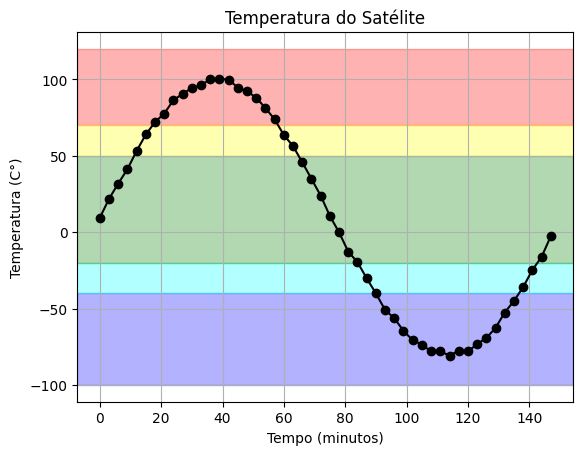

In [13]:
# eixo X e eixo Y
import matplotlib.pyplot as plt
tempos = [item[0] for item in lista_classificacoes]
temperaturas = [item[1] for item in lista_classificacoes]

plt.plot(tempos, temperaturas, color='black', marker='o')

# pintando por frescuragem
plt.axhspan(-100, -40, color='blue', alpha=0.3) # pinta de azul o Code Case Crítico # alpha é a transparencia
# ele começa na altura y = -100 e vai até a altura y = -40
plt.axhspan(70, 120, color='red', alpha=0.3) # pinta de vermelho o Hot Case Crítico
# ele começa na altura y = 70 e vai até a altura y = 120
plt.axhspan(-40, -20, color='cyan', alpha=0.3)
plt.axhspan(50, 70, color='yellow', alpha=0.3 )
plt.axhspan(-20, 50, color='green', alpha=0.3)

plt.title('Temperatura do Satélite')
plt.xlabel('Tempo (minutos)')
plt.ylabel('Temperatura (C°)')

plt.grid(True)
plt.show()